# Compare model performance: easy vs hard cities (timezone) and easy vs hard currencies

Uses definitions from config files:
- **Timezone**: `conversions/timezone.json` → `city_popularity.easy` / `city_popularity.hard`
- **Currency**: `conversions/currency.json` → `easy_currencies` / `hard_currencies`

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json
import re
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from config import MODEL_CONFIGS

def model_sort_order(models):
    """Sort models: non-reasoning first, then reasoning; alphabetically within each group."""
    return sorted(models, key=lambda m: (MODEL_CONFIGS.get(m, {}).get('reasoning', False), m))

## Load easy/hard definitions from configs

In [22]:
CONVERSIONS_DIR = Path('conversions')

with open(CONVERSIONS_DIR / 'timezone.json') as f:
    tz_config = json.load(f)
EASY_CITIES = set(tz_config['city_popularity']['easy'])
HARD_CITIES = set(tz_config['city_popularity']['hard'])

with open(CONVERSIONS_DIR / 'currency.json') as f:
    curr_config = json.load(f)
EASY_CURRENCIES = set(curr_config['easy_currencies'])
HARD_CURRENCIES = set(curr_config['hard_currencies'])

print('Timezone — easy cities:', sorted(EASY_CITIES))
print('Timezone — hard cities:', sorted(HARD_CITIES))
print('Currency — easy:', sorted(EASY_CURRENCIES))
print('Currency — hard:', sorted(HARD_CURRENCIES))

Timezone — easy cities: ['Delhi', 'Dhaka', 'Istanbul', 'Jakarta', 'London', 'Los Angeles', 'Manila', 'New York', 'Shanghai', 'Tokyo']
Timezone — hard cities: ['Altoona', 'Hilo', 'Kafue', 'Lavrentiya', 'Llieda', 'Nagai', 'Noorabad', 'Salem', 'Yorba Linda', 'Zhemuzhen']
Currency — easy: ['AUD', 'CAD', 'CHF', 'CNH', 'EUR', 'GBP', 'JPY', 'USD']
Currency — hard: ['GNF', 'IDR', 'IRR', 'LAK', 'LBP', 'SLL', 'UZS', 'VND']


## Load all converted results from full_results

In [23]:
BASE_DIR = Path('full_results')
CONDITIONS = {
    'regular':   'results',
    'no_guide':  'results_no_guide',
    'math_only': 'results_math_only',
}
SUBDIR_TO_CONDITION = {v: k for k, v in CONDITIONS.items()}

def parse_model(p: Path) -> str:
    return p.parts[-2]
def parse_cond(p: Path) -> str:
    return SUBDIR_TO_CONDITION.get(p.parts[-3], p.parts[-3])
def parse_domain(p: Path) -> str:
    name = p.parts[-1].replace('_converted', '').replace('_math_only', '').replace('_no_guide', '').replace('.tsv', '')
    return name

frames = []
for f in sorted(BASE_DIR.glob('*/*/*_converted.tsv')):
    try:
        df = pd.read_csv(f, sep='\t')
        df = df.assign(model=parse_model(f), condition=parse_cond(f), file_domain=parse_domain(f))
        frames.append(df)
    except Exception as e:
        print(f"Could not read {f}: {e}")

df_all = pd.concat(frames, ignore_index=True)
df_all['is_correct'] = (df_all['loss'].fillna(np.nan).values == 0)
print(f"Loaded {len(df_all):,} rows. Domains: {sorted(df_all['file_domain'].unique())}")

Loaded 2,943,098 rows. Domains: ['bits_bytes', 'clothing_sizes_men_pant_size', 'clothing_sizes_men_shoe_size', 'clothing_sizes_women_bra_size', 'clothing_sizes_women_pant_size', 'clothing_sizes_women_shoe_size', 'cooking', 'currency', 'density', 'energy', 'moles_to_particles', 'speed', 'temperature', 'timezone', 'volume']


## Parse prompts and assign easy/hard (cities and currencies)

In [24]:
# Timezone: "Convert 9PM in Los Angeles time to New York time."
tz_pat = re.compile(r'Convert\s+.+?\s+in\s+(.+?)\s+time\s+to\s+(.+?)\s+time', re.IGNORECASE)

def get_tz_cities(prompt):
    if pd.isna(prompt):
        return None, None
    m = tz_pat.search(str(prompt).strip())
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return None, None

def city_pair_difficulty(from_city, to_city):
    if from_city is None or to_city is None:
        return None
    from_easy = from_city in EASY_CITIES
    to_easy = to_city in EASY_CITIES
    from_hard = from_city in HARD_CITIES
    to_hard = to_city in HARD_CITIES
    if from_easy and to_easy:
        return 'easy'
    if from_hard and to_hard:
        return 'hard'
    return 'mixed'

# Currency: "Convert 123.45 USD to EUR." or "Convert 1000 EUR to GBP."
curr_pat = re.compile(r'Convert\s+[\d.,eE+-]+\s+([A-Z]{3})\s+to\s+([A-Z]{3})')

def get_curr_pair(prompt):
    if pd.isna(prompt):
        return None, None
    m = curr_pat.search(str(prompt).strip())
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return None, None

def currency_pair_difficulty(from_curr, to_curr):
    if from_curr is None or to_curr is None:
        return None
    from_easy = from_curr in EASY_CURRENCIES
    to_easy = to_curr in EASY_CURRENCIES
    from_hard = from_curr in HARD_CURRENCIES
    to_hard = to_curr in HARD_CURRENCIES
    if from_easy and to_easy:
        return 'easy'
    if from_hard and to_hard:
        return 'hard'
    return 'mixed'

In [25]:
# Timezone: add city difficulty
df_tz = df_all[df_all['file_domain'] == 'timezone'].copy()
parsed = df_tz['prompt'].apply(get_tz_cities)
df_tz['from_city'] = [p[0] for p in parsed]
df_tz['to_city'] = [p[1] for p in parsed]
df_tz['city_difficulty'] = df_tz.apply(lambda r: city_pair_difficulty(r['from_city'], r['to_city']), axis=1)
df_tz_valid = df_tz[df_tz['city_difficulty'].isin(['easy', 'hard'])].copy()
print(f"Timezone: {len(df_tz):,} rows → {len(df_tz_valid):,} easy+hard (dropped mixed/unknown)")
print(df_tz_valid.groupby('city_difficulty').size())

# Currency: add currency difficulty
df_curr = df_all[df_all['file_domain'] == 'currency'].copy()
parsed_c = df_curr['prompt'].apply(get_curr_pair)
df_curr['from_currency'] = [p[0] for p in parsed_c]
df_curr['to_currency'] = [p[1] for p in parsed_c]
df_curr['currency_difficulty'] = df_curr.apply(lambda r: currency_pair_difficulty(r['from_currency'], r['to_currency']), axis=1)
df_curr_valid = df_curr[df_curr['currency_difficulty'].isin(['easy', 'hard'])].copy()
print(f"\nCurrency: {len(df_curr):,} rows → {len(df_curr_valid):,} easy+hard (dropped mixed/unknown)")
print(df_curr_valid.groupby('currency_difficulty').size())

Timezone: 194,400 rows → 129,600 easy+hard (dropped mixed/unknown)
city_difficulty
easy    64800
hard    64800
dtype: int64

Currency: 313,200 rows → 208,800 easy+hard (dropped mixed/unknown)
currency_difficulty
easy    104800
hard    104000
dtype: int64


## Timezone: accuracy by model and city difficulty (easy vs hard)

In [26]:
tz_agg = df_tz_valid.groupby(['model', 'condition', 'city_difficulty']).agg(
    n=('is_correct', 'count'),
    correct=('is_correct', 'sum'),
).reset_index()
tz_agg['accuracy_%'] = 100 * tz_agg['correct'] / tz_agg['n']

# Pivot for readability: one row per model x condition, columns easy/hard
tz_pivot = tz_agg.pivot_table(
    index=['model', 'condition'], columns='city_difficulty',
    values=['accuracy_%', 'n'], aggfunc='first'
)
tz_pivot.columns = [f"{b}_{a}" for a, b in tz_pivot.columns]
tz_pivot = tz_pivot.reset_index()
print('Timezone — accuracy % and sample size by model, condition, and city difficulty:')
display(tz_pivot)

Timezone — accuracy % and sample size by model, condition, and city difficulty:


,model,condition,easy_accuracy_%,hard_accuracy_%,easy_n,hard_n
0,deepseek-v3.1,no_guide,93.055556,62.537037,5400,5400
1,deepseek-v3.1,regular,96.277778,82.444444,5400,5400
2,gpt-4o,no_guide,37.629630,2.055556,5400,5400
3,gpt-4o,regular,46.240741,26.814815,5400,5400
4,gpt-5.2,no_guide,95.981481,75.222222,5400,5400
5,gpt-5.2,regular,99.944444,99.888889,5400,5400
6,llama-4,no_guide,2.222222,2.222222,5400,5400
7,llama-4,regular,2.222222,2.222222,5400,5400
8,qwen-coder,no_guide,49.018519,3.722222,5400,5400
9,qwen-coder,regular,29.462963,4.814815,5400,5400


NameError: name 'mpatches' is not defined

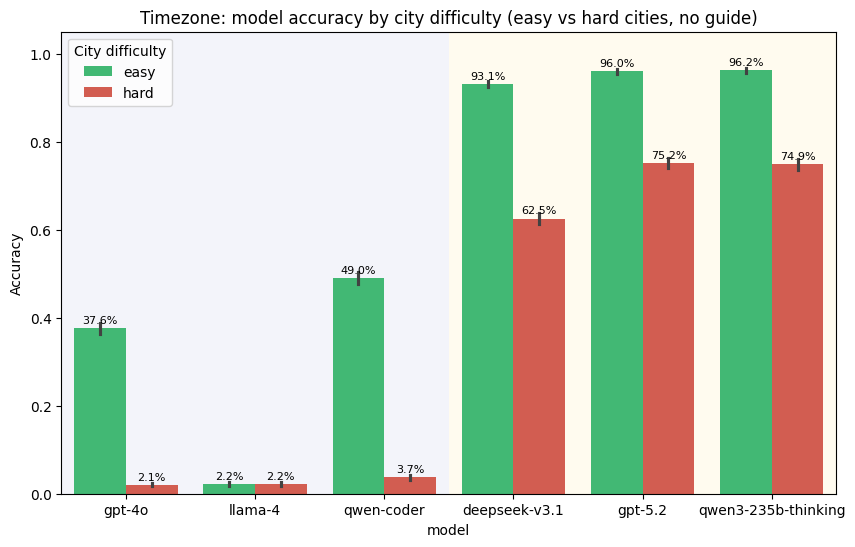

In [37]:
# Plot: regular condition only, timezone easy vs hard per model
tz_plot = df_tz_valid[df_tz_valid['condition'] == 'no_guide']
if len(tz_plot):
    fig, ax = plt.subplots(figsize=(10, 6))
    order = model_sort_order(tz_plot['model'].unique())
    split = next((i for i, m in enumerate(order) if MODEL_CONFIGS.get(m, {}).get('reasoning', False)), len(order))
    for span_start, span_end, color in [(-0.5, split - 0.5, '#e8eaf6'), (split - 0.5, len(order) - 0.5, '#fff8e1')]:
        if span_end > span_start:
            ax.axvspan(span_start, span_end, facecolor=color, alpha=0.5, zorder=0)
    sns.barplot(data=tz_plot, x='model', y='is_correct', hue='city_difficulty',
                order=order, estimator='mean', errorbar=('ci', 95), n_boot=5000, seed=42,
                palette={'easy': '#2ecc71', 'hard': '#e74c3c'}, ax=ax, zorder=1)
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{100*x:.1f}%', fontsize=8, padding=2)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.set_title('Timezone: model accuracy by city difficulty (easy vs hard cities, no guide)')
    leg1 = ax.legend(title='City difficulty')
    patch_non = mpatches.Patch(facecolor='#e8eaf6', edgecolor='gray', alpha=0.8, label='Non-reasoning')
    patch_reason = mpatches.Patch(facecolor='#fff8e1', edgecolor='gray', alpha=0.8, label='Reasoning')
    ax.add_artist(leg1)
    ax.legend(handles=[patch_non, patch_reason], title='Model type', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Currency: accuracy by model and currency difficulty (easy vs hard)

In [28]:
curr_agg = df_curr_valid.groupby(['model', 'condition', 'currency_difficulty']).agg(
    n=('is_correct', 'count'),
    correct=('is_correct', 'sum'),
).reset_index()
curr_agg['accuracy_%'] = 100 * curr_agg['correct'] / curr_agg['n']

curr_pivot = curr_agg.pivot_table(
    index=['model', 'condition'], columns='currency_difficulty',
    values=['accuracy_%', 'n'], aggfunc='first'
)
curr_pivot.columns = [f"{b}_{a}" for a, b in curr_pivot.columns]
curr_pivot = curr_pivot.reset_index()
print('Currency — accuracy % and sample size by model, condition, and currency difficulty:')
display(curr_pivot)

Currency — accuracy % and sample size by model, condition, and currency difficulty:


,model,condition,easy_accuracy_%,hard_accuracy_%,easy_n,hard_n
0,deepseek-v3.1,no_guide,0.000000,0.125000,1000,800
1,deepseek-v3.1,regular,75.000000,70.375000,1000,800
2,gpt-4o,no_guide,0.375000,0.196429,11200,11200
3,gpt-4o,regular,76.071429,39.330357,11200,11200
4,gpt-5.2,no_guide,0.026786,0.214286,11200,11200
5,gpt-5.2,regular,98.705357,98.857143,11200,11200
6,gpt-oss-120b,no_guide,0.696429,0.053571,5600,5600
7,gpt-oss-120b,regular,81.017857,44.428571,5600,5600
8,llama-4,no_guide,0.089286,0.258929,11200,11200
9,llama-4,regular,79.571429,89.526786,11200,11200


NameError: name 'mpatches' is not defined

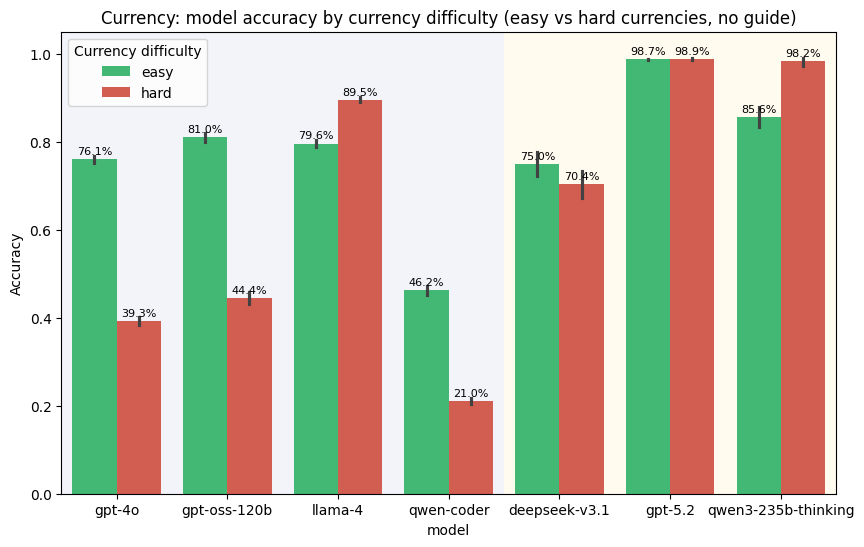

In [36]:
# Plot: regular condition only, currency easy vs hard per model
curr_plot = df_curr_valid[df_curr_valid['condition'] == 'regular']
if len(curr_plot):
    fig, ax = plt.subplots(figsize=(10, 6))
    order = model_sort_order(curr_plot['model'].unique())
    split = next((i for i, m in enumerate(order) if MODEL_CONFIGS.get(m, {}).get('reasoning', False)), len(order))
    for span_start, span_end, color in [(-0.5, split - 0.5, '#e8eaf6'), (split - 0.5, len(order) - 0.5, '#fff8e1')]:
        if span_end > span_start:
            ax.axvspan(span_start, span_end, facecolor=color, alpha=0.5, zorder=0)
    sns.barplot(data=curr_plot, x='model', y='is_correct', hue='currency_difficulty',
                order=order, estimator='mean', errorbar=('ci', 95), n_boot=5000, seed=42,
                palette={'easy': '#2ecc71', 'hard': '#e74c3c'}, ax=ax, zorder=1)
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{100*x:.1f}%', fontsize=8, padding=2)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.set_title('Currency: model accuracy by currency difficulty (easy vs hard currencies, no guide)')
    leg1 = ax.legend(title='Currency difficulty')
    patch_non = mpatches.Patch(facecolor='#e8eaf6', edgecolor='gray', alpha=0.8, label='Non-reasoning')
    patch_reason = mpatches.Patch(facecolor='#fff8e1', edgecolor='gray', alpha=0.8, label='Reasoning')
    ax.add_artist(leg1)
    ax.legend(handles=[patch_non, patch_reason], title='Model type', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Summary: easy vs hard gap by model (regular condition)

In [30]:
def gap_table(agg_df, difficulty_col, name):
    reg = agg_df[agg_df['condition'] == 'regular']
    wide = reg.pivot(index='model', columns=difficulty_col, values='accuracy_%')
    if 'easy' in wide.columns and 'hard' in wide.columns:
        wide['gap (easy - hard)'] = wide['easy'] - wide['hard']
    return wide

print('Timezone — accuracy % by model (regular), easy vs hard cities:')
display(gap_table(tz_agg, 'city_difficulty', 'timezone'))

print('Currency — accuracy % by model (regular), easy vs hard currencies:')
display(gap_table(curr_agg, 'currency_difficulty', 'currency'))

Timezone — accuracy % by model (regular), easy vs hard cities:


city_difficulty,easy,hard,gap (easy - hard)
model,,,
deepseek-v3.1,96.277778,82.444444,13.833333
gpt-4o,46.240741,26.814815,19.425926
gpt-5.2,99.944444,99.888889,0.055556
llama-4,2.222222,2.222222,0.000000
qwen-coder,29.462963,4.814815,24.648148
qwen3-235b-thinking,99.981481,99.944444,0.037037


Currency — accuracy % by model (regular), easy vs hard currencies:


currency_difficulty,easy,hard,gap (easy - hard)
model,,,
deepseek-v3.1,75.000000,70.375000,4.625000
gpt-4o,76.071429,39.330357,36.741071
gpt-5.2,98.705357,98.857143,-0.151786
gpt-oss-120b,81.017857,44.428571,36.589286
llama-4,79.571429,89.526786,-9.955357
qwen-coder,46.196429,21.035714,25.160714
qwen3-235b-thinking,85.600000,98.250000,-12.650000
